In [1]:
from matplotlib.axes import Axes
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable

from main import load_img, channel_correction
from common import OrderedImage, Stats
from clahe import tclahe
from metrics import uciqe, mse, psnr, ssim

def score_stages(img: OrderedImage, score_func: Callable[[OrderedImage], float]) -> tuple[float, float, float]:
    og_img = img.clone()

    channel_correction(img)

    # img_clahed = basic_CLAHE_float(corrected_img)
    img_clahed = tclahe(img, n=32, interpolate=True)

    return (score_func(og_img), score_func(img), score_func(img_clahed))

@dataclass
class Dataset:
    name: str
    paths: list[Path]
    imgs: list[OrderedImage]

    @staticmethod
    def from_dir(dataset_name: str, dir_path: Path) -> 'Dataset':
        paths = sorted(Path(dir_path).iterdir())
        imgs = [load_img(path) for path in paths]
        return Dataset(dataset_name, paths, imgs)

datasets = (
    Dataset.from_dir('TURBID Milk', Path('milk')),
    Dataset.from_dir('TURBID Deepblue', Path('deepblue'))
)

# print('MILK')
# milk_uciqe = np.asarray([eval_img(path) for path in milk_paths])
# print('DEEPBLUE')
# deepblue_uciqe = np.asarray([eval_img(path) for path in deepblue_paths])


In [2]:
for dataset in datasets:
    print(Stats.from_img(dataset.imgs[0]))

c0: 0.0 < μ=0.3771173850572395 < 0.6666666865348816
c1: 0.0470588244497776 < μ=0.40879892665158757 < 0.7764706015586853
c2: 0.03529411926865578 < μ=0.41897517754740493 < 0.8901960849761963

c0: 0.22745098173618317 < μ=0.4433110042088264 < 0.9960784316062927
c1: 0.16862745583057404 < μ=0.43020835950672426 < 1.0
c2: 0.06666667014360428 < μ=0.4176902610635372 < 1.0



In [6]:
metrics: list[dict[str, np.ndarray]] = []

for dataset in datasets:
    print('Scoring', dataset.name)
    metrics.append({
        'UCIQE': np.asarray([score_stages(img, uciqe) for img in dataset.imgs]),
        'MSE': np.asarray([score_stages(img, lambda test_img: mse(dataset.imgs[0], test_img)) for img in dataset.imgs]),
        'PSNR': np.asarray([score_stages(img, lambda test_img: psnr(dataset.imgs[0], test_img)) for img in dataset.imgs]),
        'SSIM': np.asarray([score_stages(img, lambda test_img: ssim(dataset.imgs[0], test_img)) for img in dataset.imgs]),
    })

NUM_METRICS = 4

Scoring TURBID Milk


/home/user/Documents/cwru/MS/underwater-image-enhancement/venv/lib/python3.12/site-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


Scoring TURBID Deepblue


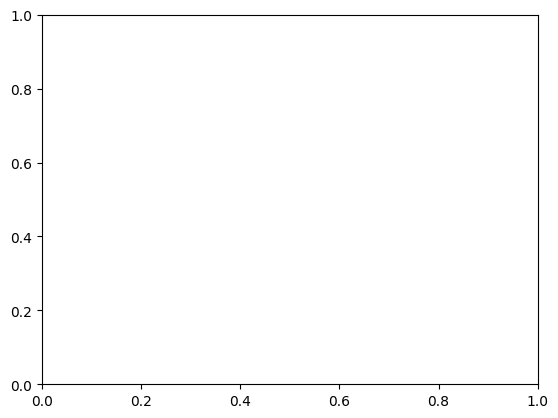

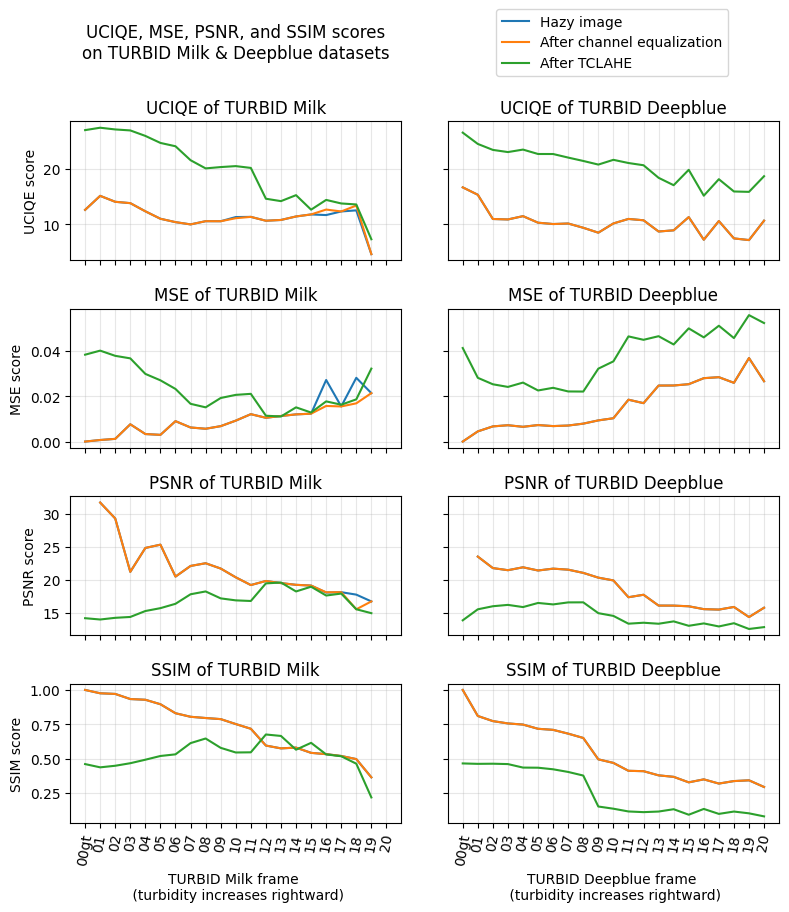

In [96]:
def plot_scores(dataset_name: str, metric_name: str, paths: list[Path], scores: np.ndarray, axes: Axes = plt.gca()):
    axes.grid(alpha=0.3)
    axes.plot(scores, label=('Hazy image', 'After channel equalization', 'After TCLAHE'))
    axes.set_xticks(range(0, len(paths)), [path.stem for path in paths], rotation=80)
    axes.set(
        title=f'{metric_name} of {dataset_name}',
        ylabel=f'{metric_name} score',
        xlabel=f'{dataset_name} frame \n (turbidity increases rightward)'
    )
    # axes.legend(loc='upper right')

fig, axs = plt.subplots(nrows=NUM_METRICS, ncols=len(datasets), sharex=True, sharey='row')
fig.tight_layout()
fig.set_size_inches(8, 8)
for d, dataset in enumerate(datasets):
    for m, (metric_name, scores) in enumerate(metrics[d].items()):
        ax = axs.flat[m * len(datasets) + d]
        plot_scores(dataset.name, metric_name, dataset.paths, scores, axes=ax)
        ax.label_outer()

plt.suptitle('UCIQE, MSE, PSNR, and SSIM scores\non TURBID Milk & Deepblue datasets', x=0.28, y=1.08)
plt.legend(loc='upper left', bbox_to_anchor=(0.125, 5.9))
# plt.tight_layout()
plt.show()